# **Algorithm : GBM**

## **Project:**
*  Customer Purchase Prediction

### **Problem Statement:**

* Predict whether customers will purchase products based on behavior data.

In [29]:
# Step No 1 : Import Required Libraries 
# Import Pandas for data manipulation and analysis
import pandas as pd 

# Import numpy for  numerical operations 
import numpy as np 

# Import matplotlib for data visualization
import matplotlib.pyplot as plt 

# Import seaborn for statistical data visualization
import seaborn as sns

# Import Machine Learning Libraries 
# Import train_test_split to split the dataset into training and testing data 
from sklearn.model_selection import train_test_split

#Import Gradient Boosting Classifier to build the GBM classification model
from sklearn.ensemble import GradientBoostingClassifier

# Import Evaluation metrics 
from sklearn.metrics import(accuracy_score,
                            precision_score,
                            recall_score,
                            f1_score,
                            confusion_matrix,
                            classification_report,
                            roc_auc_score,
                            roc_curve)

In [30]:
# Step No 2 : Load Dataset 
df = pd.read_csv("customer_purchase_prediction_gbm_dataset.csv")
# Display the first 5 rows of the dataset 
df.head()

,Customer_ID,Age,Income,Pages_Viewed,Session_Duration_Min,Products_Viewed,Cart_Additions,Previous_Purchases,Discount_Used,Email_Opened,Mobile_User,Purchased
0,C00001,56,28224,10,4.4,1,0,2,0,0,1,0
1,C00002,46,55738,4,3.4,9,0,1,1,1,1,0
2,C00003,32,78731,9,5.6,4,3,1,0,0,0,1
3,C00004,60,23070,7,14.7,15,2,1,0,1,1,1
4,C00005,25,141161,6,4.3,2,0,3,1,1,1,0


In [31]:
# Step No : 3 Data Understanding 

# Display first five rows 
print(df.head())

# Display dataset Shape 
print("\nDataset Shape : ")
print(df.shape)

# Display Column Names 
print("\nColumn Names : ")
print(df.columns.tolist())

# Display dataset information 
print("\nDataset Information : ")
print(df.info())

# Display Statistical information 
print("\nStatistical Summary : ")
print(df.describe(include="all"))

  Customer_ID  Age  Income  Pages_Viewed  Session_Duration_Min  \
0      C00001   56   28224            10                   4.4   
1      C00002   46   55738             4                   3.4   
2      C00003   32   78731             9                   5.6   
3      C00004   60   23070             7                  14.7   
4      C00005   25  141161             6                   4.3   

   Products_Viewed  Cart_Additions  Previous_Purchases  Discount_Used  \
0                1               0                   2              0   
1                9               0                   1              1   
2                4               3                   1              0   
3               15               2                   1              0   
4                2               0                   3              1   

   Email_Opened  Mobile_User  Purchased  
0             0            1          0  
1             1            1          0  
2             0            0          

In [32]:
# Step No 4 : Dataset Cleaning 
# Check Missing Values 
print("\nMissing Values : ")
print(df.isnull().sum())

# Check Duplicate Rows 
print("\nDuplicate Values : ")
print(df.duplicated().sum())

# Remove Duplicated values
df = df.drop_duplicates()




Missing Values : 
Customer_ID             0
Age                     0
Income                  0
Pages_Viewed            0
Session_Duration_Min    0
Products_Viewed         0
Cart_Additions          0
Previous_Purchases      0
Discount_Used           0
Email_Opened            0
Mobile_User             0
Purchased               0
dtype: int64

Duplicate Values : 
0


In [33]:
# Step No 5 : Check Target Variable 
print(df["Purchased"].value_counts())

# 0 = Customer did not purchase the product
# 1 = Customer purchased the product

Purchased
0    640
1    560
Name: count, dtype: int64


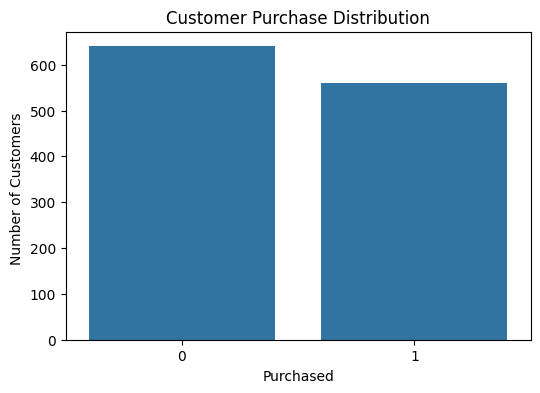

In [34]:
# Step No 6 : Visualize Target Variable

# Set the figure size 
plt.figure(figsize=(6 , 4))

#Create a count plot for the Purchased column
sns.countplot(x="Purchased" , data=df)

# Add a title to the graph
plt.title("Customer Purchase Distribution")

# Add label to the X-axis 
plt.xlabel("Purchased")

# Add label to the Y-axis 
plt.ylabel("Number of Customers ")

# Display the graph 
plt.show()

In [35]:
# Step No 7 : Calculate Purchase Percentage
# Calculate the percentage of customers in each purchase class
purchase_percentage = df["Purchased"].value_counts(normalize=True) * 100

# Display the purchase percentage 
print(purchase_percentage)

Purchased
0    53.333333
1    46.666667
Name: proportion, dtype: float64


In [36]:
# Step No 8 : Correlation Analysis
# Remove Customer_ID because it is only an identification column
corr_data = df.drop(columns=["Customer_ID"])

# Calculate the correlation matrix 
correlation = corr_data.corr()

# Display the correlation matrix 
print(correlation)

                           Age    Income  Pages_Viewed  Session_Duration_Min  \
Age                   1.000000  0.011424     -0.025024              0.020696   
Income                0.011424  1.000000     -0.004720             -0.000433   
Pages_Viewed         -0.025024 -0.004720      1.000000             -0.070021   
Session_Duration_Min  0.020696 -0.000433     -0.070021              1.000000   
Products_Viewed      -0.023829 -0.045341     -0.029065             -0.018308   
Cart_Additions        0.025410  0.029017      0.020565             -0.014481   
Previous_Purchases   -0.012370  0.040721     -0.004892              0.046846   
Discount_Used         0.021976  0.012263      0.054708              0.048239   
Email_Opened          0.011690 -0.052333      0.056628             -0.034050   
Mobile_User           0.031816 -0.051791      0.028738              0.029113   
Purchased            -0.000709  0.097164      0.011133              0.098631   

                      Products_Viewed  

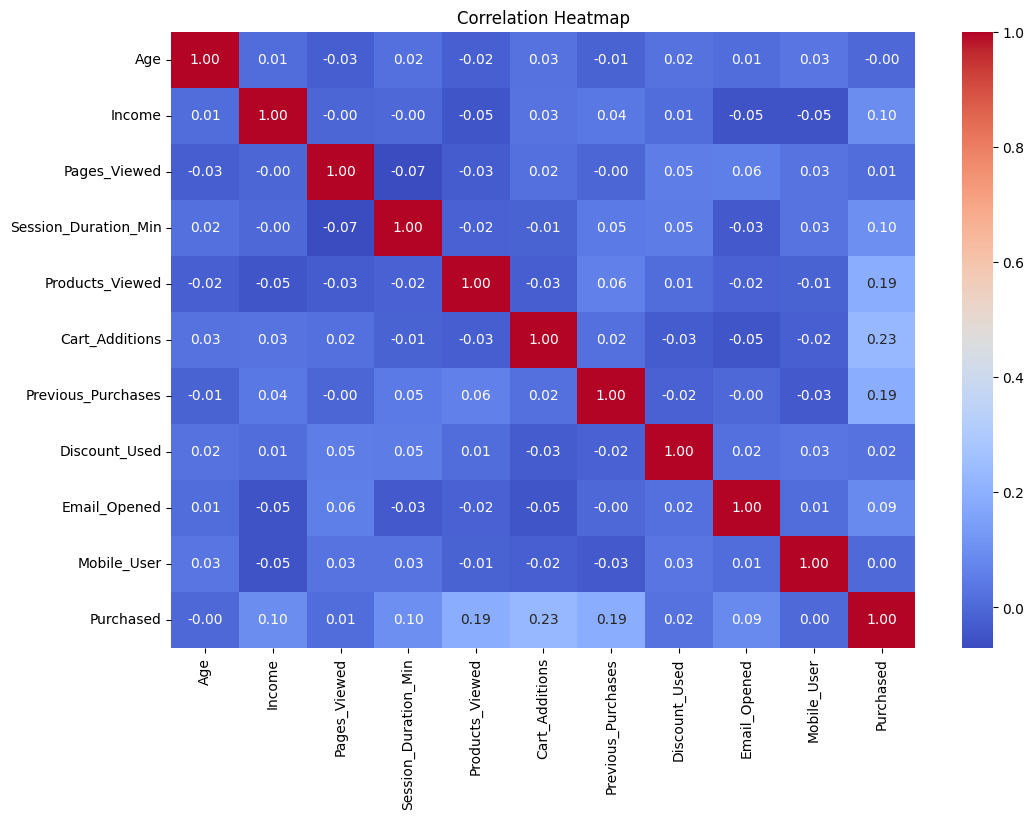

In [37]:
# Step No 9 : Correlation Heatmap

# Set the figure size
plt.figure(figsize=(12, 8))

# Create a heatmap using the correlation matrix
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Add a title to the heatmap
plt.title("Correlation Heatmap")

# Display the heatmap
plt.show()

In [38]:
# Step No 10 : Define Features and Target 
# Create the input features by removing Customer_ID and Purchased
X = df.drop(columns=["Customer_ID" , "Purchased"])

# Create the target variable using the Purchased column
y = df["Purchased"]

# Display the feature columns
print("Features : ")
print(X.columns)

# Display the target variable name 
print("\nTarget : ")
print(y.name)

Features : 
Index(['Age', 'Income', 'Pages_Viewed', 'Session_Duration_Min',
       'Products_Viewed', 'Cart_Additions', 'Previous_Purchases',
       'Discount_Used', 'Email_Opened', 'Mobile_User'],
      dtype='object')

Target : 
Purchased


In [39]:
# Step No 11 : Check X and y Shape 
# Display the shape of the input features 
print("X Shape : " , X.shape)

# Display the shape of the target variable 
print("y Shape : " , y.shape)

X Shape :  (1200, 10)
y Shape :  (1200,)


In [40]:
# Step No 12 : Train - Test Split
# 80% data for training
# 20% data for testing
# Split the dataset into training and testing sets 
X_train , X_test , y_train , y_test = train_test_split(
    # Input features 
    X , 
    # Target Variable 
    y,
    # Use 20% of the data for testing 
    test_size=0.20,
    
    # Set random_state for reproducible results 
    random_state=42,
    
    # Maintain the same target class proportion in train and test data 
    stratify=y 
)

# Check Train - Test Data 
# Display the shape of training features 
print("X_train : " , X_train.shape)

# Display the shape of testing features 
print("X_test : " , X_test.shape)

# Display the shape of training target 
print("y_train : " , y_train.shape)

# Display the shape of testing target
print("y_test : " , y_test.shape)

X_train :  (960, 10)
X_test :  (240, 10)
y_train :  (960,)
y_test :  (240,)


In [41]:
# Step No 13 : Create GBM Model 
# Create a Gradient Boosting Classifier Model 
gbm_model = GradientBoostingClassifier(
    # Number of boosting stages 
    n_estimators=100 , 
    # Learning rate controls the contribution of each tree
    learning_rate= 0.10 , 
    # Maximum depth of each decision tree
    max_depth= 3 , 
    # Set random_state for reproducible results 
    random_state=42
)



In [42]:
# Step No 14 : Train GBM Model 
gbm_model.fit(X_train , y_train)

GradientBoostingClassifier(random_state=42)

In [43]:
# Step No 15 : Make Predictions 
y_pred = gbm_model.predict(X_test)

# Display the first 20 predictions 
print(y_pred[:20])

[0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0]


In [44]:
# Step No 16 : Get Prediction Probabilities  
# Calculate the probability of each customer purchasing the product 
# [: , 1 ] selects the probability of class 1
y_pred_proba = gbm_model.predict_proba(X_test)[: , 1]

# Display the first 10 purchase probabilities 
print(y_pred_proba[:10])

[0.34095795 0.24452198 0.422134   0.10051712 0.18839862 0.05220702
 0.11256581 0.31111944 0.53876631 0.37895965]


In [45]:
# Step No 17 : Evaluation Metrics 
# Calculate the accuracy of the GBM model 
accuracy = accuracy_score(y_test , y_pred)

# Display the accuracy 
print("Accuracy : " , accuracy)

# Display the accuracy as a percentage 
print("Accuracy Percentage : " , accuracy * 100)

# Calculate the precision of the GBM model 
precision = precision_score(y_test , y_pred)
# Display the precision score 
print("Precision : " , precision)

# Calculate the recall of the GBM model
recall = recall_score(y_test , y_pred)
# Display the recall score 
print("Recall : " , recall)

#Calculate the F1 score of the GBM model 
f1 = f1_score(y_test , y_pred)
# Display the F1 score 
print("F1 Score : " , f1)

# Calculate ROC-AUC Score 
roc_auc = roc_auc_score(y_test , y_pred_proba)
# Display the ROC-AUC score 
print("ROC-AUC Score : " , roc_auc)

# Generate a detailed classification report 
report = classification_report(y_test , y_pred)
# Display the classification report 
print(report)

#Create a confusion matrix using actual and predicted 
cm = confusion_matrix(y_test , y_pred)
# Display the confusion matrix 
print(cm)

# Display All Evaluation Metrics 
# Display the model performance heading 
print("========== GBM MODEL PERFORMANCE ===========")

# Display accuracy
print("Accuracy : " , round(accuracy , 4))

# Display precision
print("Precision : " , round(precision , 4))

# Display recall
print("Recall : " , round(recall , 4))

# Display F1 score 
print("F1 Score : " , round(f1 , 4))

# Display ROC - AUC score 
print("ROC - AUC : " , round(roc_auc , 4))

Accuracy :  0.5958333333333333
Accuracy Percentage :  59.583333333333336
Precision :  0.5757575757575758
Recall :  0.5089285714285714
F1 Score :  0.5402843601895735
ROC-AUC Score :  0.6416713169642858
              precision    recall  f1-score   support

           0       0.61      0.67      0.64       128
           1       0.58      0.51      0.54       112

    accuracy                           0.60       240
   macro avg       0.59      0.59      0.59       240
weighted avg       0.59      0.60      0.59       240

[[86 42]
 [55 57]]
========== GBM MODEL PERFORMANCE ===========
Accuracy :  0.5958
Precision :  0.5758
Recall :  0.5089
F1 Score :  0.5403
ROC - AUC :  0.6417


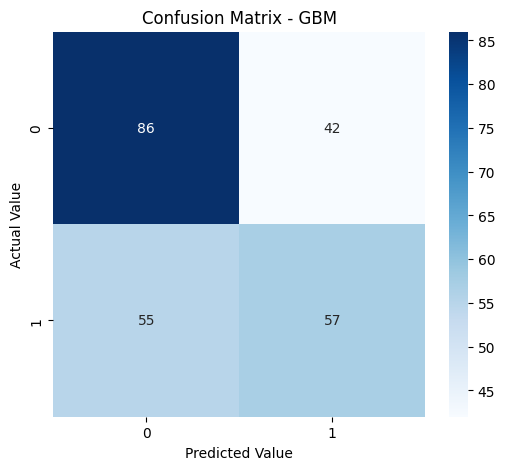

In [46]:
# Step No 18 : Visualize Confusion Matrix 
# Set the figure size 
plt.figure(figsize=(6,5))

# Create a heatmap of the confusion matrix 
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Add a title to the graph
plt.title("Confusion Matrix - GBM")

# Add label to the X=axis 
plt.xlabel("Predicted Value")

# Add label to the Y-axis 
plt.ylabel("Actual Value")

# Display the graph 
plt.show()

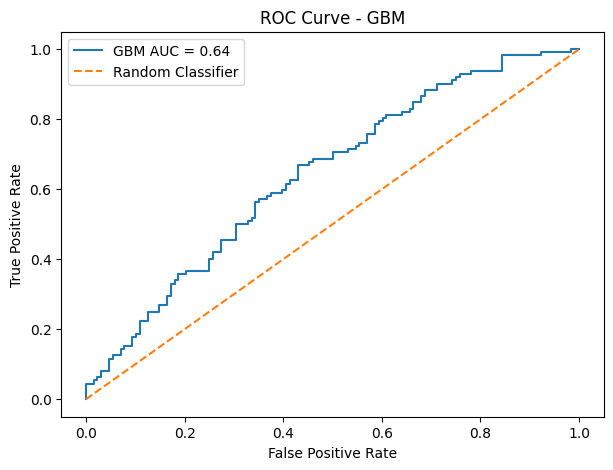

In [47]:
# Step No 19 : Create ROC Curve

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

# Set the figure size
plt.figure(figsize=(7, 5))

# Plot the ROC curve
plt.plot(
    fpr,
    tpr,
    label=f"GBM AUC = {roc_auc:.2f}"
)

# Plot the random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

# Add label to the X-axis
plt.xlabel("False Positive Rate")

# Add label to the Y-axis
plt.ylabel("True Positive Rate")

# Add a title to the graph
plt.title("ROC Curve - GBM")

# Display the legend
plt.legend()

# Display the graph
plt.show()

In [48]:
# Step No 20 : Feature Importance 
# Create a DataFrame containing feature names and their importance
feature_importance = pd.DataFrame({
    # Store feature names 
    "Feature" : X.columns,
    
    # Store feature importance values from the GBM model
    "Importance":gbm_model.feature_importances_
})

# Sort feature from highest to lowest importance 
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
print(feature_importance)

                Feature  Importance
1                Income    0.227066
4       Products_Viewed    0.166564
3  Session_Duration_Min    0.158769
5        Cart_Additions    0.150329
0                   Age    0.101069
6    Previous_Purchases    0.097429
8          Email_Opened    0.047786
2          Pages_Viewed    0.042538
7         Discount_Used    0.005323
9           Mobile_User    0.003127


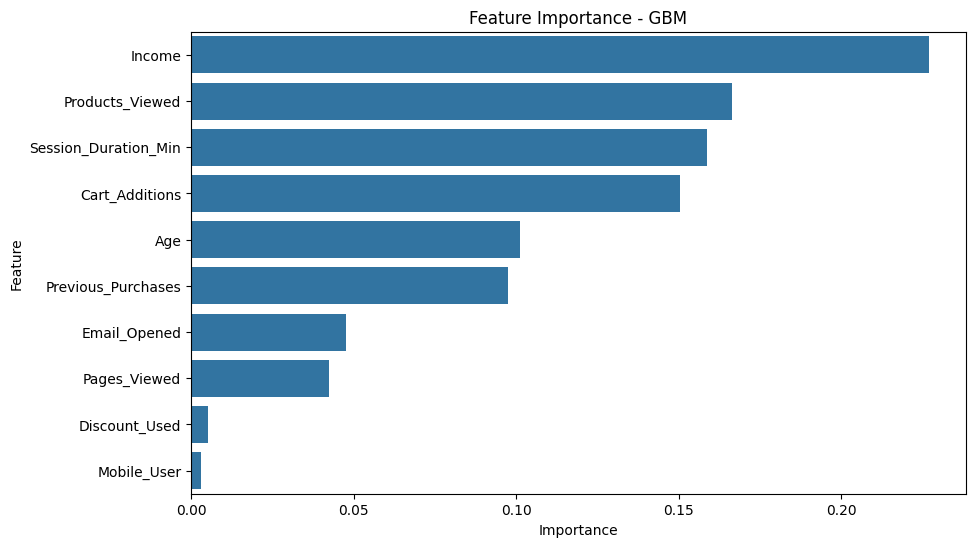

In [49]:
# Step No 21 : Feature Importance Visualization
# Set the figure size 
plt.figure(figsize=(10 , 6))

# Create a bar plot of feature importance 
sns.barplot(
    x = "Importance",
    y = "Feature",
    data = feature_importance
)

# Add a title to the graph 
plt.title("Feature Importance - GBM")

# Display the graph
plt.show()

In [50]:
# Step No 22 : Display Top 5 Features 
# Display the top 5 moset important features
print("Top 5 Important Features : ")

# Select and display the first 5 rows 
print(feature_importance.head(5))

Top 5 Important Features : 
                Feature  Importance
1                Income    0.227066
4       Products_Viewed    0.166564
3  Session_Duration_Min    0.158769
5        Cart_Additions    0.150329
0                   Age    0.101069


In [51]:
# Step No 23 : Actual Vs Predicted Values 
results = pd.DataFrame({
    # Store actual purchase values 
    "Actual":y_test.values , 
    # Store predicted purchase values
    "Predicted": y_pred
})

# Display the first 20 predictions
results.head(20)

,Actual,Predicted
0,0,0
1,1,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,0
8,1,1
9,0,0


In [52]:
# Step No 24 : Create a New Customer 
# Create data for a new customer 
new_customer = pd.DataFrame({
    # Customer age
    "Age": [30],
    
    # Customer annual income
    "Income": [75000],
    
    # Number of pages viewed by the customer 
    "Pages_Viewed" : [10] , 
    
    # Session duration in minutes
    "Session_Duration_Min": [15.5],
    
    # Number of products viewed
    "Products_Viewed": [8],
    
    # Number of products added to cart
    "Cart_Additions": [3],
    
    # Number of previous purchases
    "Previous_Purchases": [2],
    
    # Whether the customer used a discount
    # 1 = Yes , 0 = No
    "Discount_Used": [1] ,
    
    # Whether the customer opened the email
    # 1 = yes , 0 = No
    "Email_Opened": [1] , 
    
    # Whether the customer is a mobile user
    # 1 = Yes , 0 = No
    "Mobile_User": [1]
    
})

# Display the new customer data 
new_customer

,Age,Income,Pages_Viewed,Session_Duration_Min,Products_Viewed,Cart_Additions,Previous_Purchases,Discount_Used,Email_Opened,Mobile_User
0,30,75000,10,15.5,8,3,2,1,1,1


In [53]:
# Step No 25 : Predict New Customer Purchase
# Predict whether the new customer will purchase the product 
new_prediction = gbm_model.predict(new_customer)

# Calculate the probability of purchase 
new_probability = gbm_model.predict_proba(
    new_customer
)[0][1]

# Check the prediction result
if new_prediction[0] == 1:
    # Display this message when the prediction is 1 
    print("Customer is likely ot PURCHASE.")
else:
    # Display this message when the prediction is 0
    print("Customer is NOT likely to purchase.")
    
# Display the purchase probability as a percentage
print(
    "Purchase Probability : " , 
    round(new_probability * 100 , 2),
    "%"
)

Customer is likely ot PURCHASE.
Purchase Probability :  69.02 %
